Read the data and make visualization

In [1]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")          
    print('GPU:', torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print('CPU')


GPU: Tesla T4


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import glob
import cv2

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path= glob.glob('/content/drive/MyDrive/B. Disease Grading/*')
path = path[2:]
path

['/content/drive/MyDrive/B. Disease Grading/2. Groundtruths',
 '/content/drive/MyDrive/B. Disease Grading/1. Original Images']

In [5]:
labels_path = glob.glob(path[0]+'/*')
images_path = glob.glob(path[1]+'/*')


In [6]:

images_path[0]

'/content/drive/MyDrive/B. Disease Grading/1. Original Images/b. Testing Set'

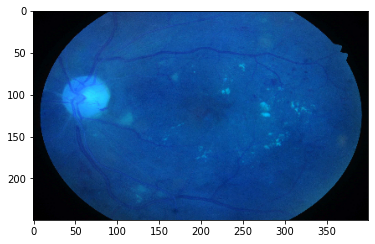

In [7]:
#import train and test images
Train, Test = [],[]

file = glob.glob(images_path[1]+'/*.jpg') # read the training path
for j in file: 
    img = cv2.imread(j)

    crop_top = 0  # row index of the top-left corner of the crop
    crop_left = 200  # column index of the top-left corner of the crop
    crop_bottom = crop_top + 3000  # row index of the bottom-right corner of the crop
    crop_right = crop_left + 3550  # column index of the bottom-right corner of the crop

    cropped_img = img[crop_top:crop_bottom, crop_left:crop_right, :]

    Train.append(cv2.resize(cropped_img,(400,250)))
    

file = glob.glob(images_path[0]+'/*.jpg') # read the test path
for j in file: 
    img = cv2.imread(j)

    crop_top = 0  # row index of the top-left corner of the crop
    crop_left = 200  # column index of the top-left corner of the crop
    crop_bottom = crop_top + 3000  # row index of the bottom-right corner of the crop
    crop_right = crop_left + 3550  # column index of the bottom-right corner of the crop

    cropped_img = img[crop_top:crop_bottom, crop_left:crop_right, :]

    Test.append(cv2.resize(cropped_img,(400,250)))
    

plt.imshow(Train[50])

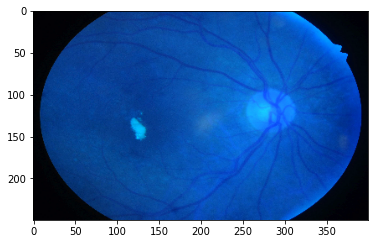

In [8]:
plt.imshow(Test[70])

In [9]:
print("trainingset contains:",len(Train),"and the testset contains ",len(Test))

trainingset contains: 413 and the testset contains  103


In [10]:
#now we are going to upload the labels 
path[0]

'/content/drive/MyDrive/B. Disease Grading/2. Groundtruths'

In [11]:
Label_train = pd.read_csv(path[0]+'/a. IDRiD_Disease Grading_Training Labels.csv')


Label_train = Label_train.iloc[:,[1,2]]
Label_train  

,Retinopathy grade,Risk of macular edema
0,3,2
1,3,2
2,2,2
3,3,2
4,4,0
...,...,...
408,2,1
409,2,0
410,2,0
411,2,0


In [15]:
Label_train['Risk of macular edema '].value_counts()


2    195
0    177
1     41
Name: Risk of macular edema , dtype: int64

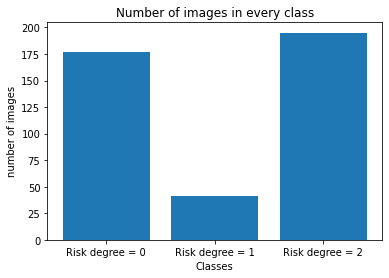

In [16]:
#x cordinates
x = np.unique(Label_train['Risk of macular edema '])
#y cordinates
y = np.array([177,41,195]) #np.unique(Label_train['Risk of macular edema '].value_counts()) 
# labels for bars
tick_label = ['Risk degree = 0', 'Risk degree = 1', 'Risk degree = 2']

# plotting a bar chart
plt.bar(x, y, tick_label = tick_label,
        width = 0.8)#, color = ['red', 'green'])
  
# naming the x-axis
plt.xlabel('Classes')
# naming the y-axis
plt.ylabel('number of images')
# plot title
plt.title('Number of images in every class')

# function to show the plot
plt.show()

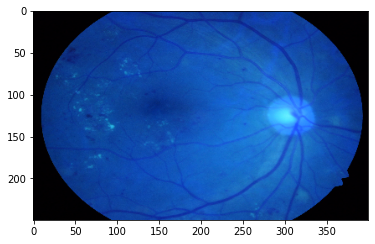

In [17]:
img = Train[0].copy()
h_flipped = cv2.flip(img,0)
plt.imshow(h_flipped)

In [18]:
#in this case our data in unbalanced, so we need to make the data augmentation to make it balanced and increase the data in the same time
number, typ= 0,0
new_Train2 = Train.copy()
new_Labels2 = Label_train.copy()
# we first have to add more 18 picture of the classe 0 and add 154 picture for class 1
for i in range(len(Train)):
    if((Label_train.iloc[i,1]) == 0 and number <18):
        number += 1
        img = Train[i].copy()
        
        flipped = cv2.flip(img, typ)
        if (typ ==0):
            typ =1
        else:
            typ=0
        
        new_Train2.append(flipped)
        new_Labels2.loc[len(new_Labels2)] = [(Label_train.iloc[i,0]), (Label_train.iloc[i,1])]

    elif((Label_train.iloc[i,1]) == 1):
        for l in range (4):
            img = Train[i].copy()
            
            flipped = cv2.flip(img, typ)
            if (typ == 0):
                typ = 1
            else:
                typ = 0
             
            new_Train2.append(flipped)
            new_Labels2.loc[len(new_Labels2)] = [(Label_train.iloc[i,0]), (Label_train.iloc[i,1])]

#Make data augmentation for all
new_Labels2 = pd.DataFrame(new_Labels2)
new_Labels = pd.DataFrame({'Retinopathy grade ': [], 'Risk of macular edema ': []})
new_Train = []
for i in range (len(new_Train2)):
  for l in range (2):
    img = new_Train2[i].copy()
        
    flipped = cv2.flip(img, typ)
    if (typ ==0):
      typ =1
    else:
      typ=0
        
    new_Train.append(flipped)
    new_Labels.loc[len(new_Labels)] = [(new_Labels2.iloc[i,0]), (new_Labels2.iloc[i,1])]


#new_Labels2 = pd.DataFrame(new_Labels2)





In [19]:
new_Labels2['Risk of macular edema '].value_counts()

1    205
2    195
0    195
Name: Risk of macular edema , dtype: int64

In [20]:
#w've made the data  from 413 to 1190
new_Labels['Risk of macular edema '].value_counts()

1    410
2    390
0    390
Name: Risk of macular edema , dtype: int64

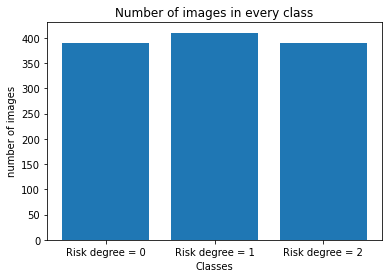

In [21]:
#x cordinates
x = np.unique(new_Labels['Risk of macular edema '])
#y cordinates
y = np.array([390,410,390]) #np.unique(Label_train['Risk of macular edema '].value_counts()) 
# labels for bars
tick_label = ['Risk degree = 0', 'Risk degree = 1', 'Risk degree = 2']

# plotting a bar chart
plt.bar(x, y, tick_label = tick_label,
        width = 0.8)#, color = ['red', 'green'])
  
# naming the x-axis
plt.xlabel('Classes')
# naming the y-axis
plt.ylabel('number of images')
# plot title
plt.title('Number of images in every class')

# function to show the plot
plt.show()

In [22]:
Label_test = pd.read_csv(path[0]+'/b. IDRiD_Disease Grading_Testing Labels.csv')

Label_test = Label_test.iloc[:,[1,2]]
Label_test  

,Retinopathy grade,Risk of macular edema
0,4,0
1,4,1
2,4,0
3,4,0
4,4,1
...,...,...
98,0,0
99,2,1
100,1,0
101,2,2


Creat the CNN for classification

In [23]:
# Before starting we need to normlize the pixels between -1 and 1:
import torchvision
import torchvision.transforms as transforms


transform = transforms.Compose([
    transforms.ToTensor(),  # convert image to PyTorch tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # normalize pixel values to be between -1 and 1
])

# Apply the transformation to the image
norm_Train = new_Train.copy()
for i in range (len(new_Train)):
  norm_Train[i]= transform(new_Train[i])



In [24]:
#import libraries
import torch
import torch.nn as nn
import torch.optim as optim


In [25]:
# Define the CNN architecture
class CNN_for_traditional(nn.Module):
    def __init__(self,in_channels = 3, num_class =3):
      super (CNN_for_traditional, self).__init__()

      self.conv1 = nn.Conv2d(in_channels=3, out_channels=9, kernel_size= (2,2) , stride=1 , padding=1)
      self.relu1 = nn.ReLU()
      self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2) 

      self.conv2 = nn.Conv2d(in_channels=9, out_channels=18,kernel_size=(3,3), stride=1, padding=1)
      self.relu2 = nn.ReLU()
      self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2) 

      self.fc1 = nn.Linear(in_features = 18*100*63, out_features=1000)
      self.relu3 = nn.ReLU()
      self.dropout1 = nn.Dropout(p=0.2)

      self.fc2 = nn.Linear(in_features = 1000, out_features = 100)
      self.relu4 = nn.ReLU()
      self.dropout2 = nn.Dropout(p=0.1)

      self.fc3 = nn.Linear(in_features = 100, out_features = 3)


      def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = x.view(-1, 18*100*63)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu4(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        #x = nn.functional.softmax(x)

        return x




In [26]:
# Define the loss function and optimizer
cnn = CNN_for_traditional()

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.SGD(cnn.parameters(), lr=0.001, momentum=0.9)


In [ ]:
# Train the model

for epoch in range(2):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs,labels = norm_Train ,np.array(Label_train['Risk of macular edema '])
        #inputs, labels = data
        optimizer.zero_grad()
        outputs = cnn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0